In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split, SubsetRandomSampler
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import normalize
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import os
import seaborn as sns

In [2]:
# PyTorch Dataset
class ECGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)  # Add channel dimension
        self.y = torch.tensor(y, dtype=torch.long)
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [3]:
# Load data
current_dir = os.getcwd()
path_train = current_dir + "/../dataset/mitbih/" + "mitbih_train.csv"
path_test = current_dir + "/../dataset/mitbih/" + "mitbih_test.csv"

df_train = pd.read_csv(path_train, header=None)
df_test = pd.read_csv(path_test, header=None)

# Drop any non-numeric column (like 'Class' from the header row)
df_train = df_train.apply(pd.to_numeric, errors='coerce')
df_test = df_test.apply(pd.to_numeric, errors='coerce')

# Remove any NaN values (in case 'Class' was still causing issues)
#df_train = df_train.dropna()
#df_test = df_test.dropna()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Split features and labels
X_train, y_train = df_train.iloc[:, :-1].values, df_train.iloc[:, -1].values
X_test, y_test = df_test.iloc[:, :-1].values, df_test.iloc[:, -1].values

reduction_factor = 0.25  # Keep 25% of the dataset

# Dataloaders
train_valid_dataset = ECGDataset(X_train, y_train)
test_dataset = ECGDataset(X_test, y_test)

batch_size = 32
train_size = int(0.8 * len(train_valid_dataset))
val_size = len(train_valid_dataset) - train_size
train_dataset, val_dataset = random_split(train_valid_dataset, [train_size, val_size])
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [23]:
class CNN(nn.Module):
    def __init__(self, input_size=187, num_classes=5):
        super(CNN, self).__init__()
        
        # Define convolutional layers
        self.conv1 = nn.Conv1d(in_channels=1, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn1 = nn.BatchNorm1d(32)
        self.relu = nn.ReLU()
        self.pool = nn.MaxPool1d(kernel_size=1, stride=2)
        
        self.conv2 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn2 = nn.BatchNorm1d(64)
        
        self.conv3 = nn.Conv1d(in_channels=64, out_channels=32, kernel_size=5, stride=1, padding=2)
        self.bn3 = nn.BatchNorm1d(32)
        
        self.conv4 = nn.Conv1d(in_channels=32, out_channels=64, kernel_size=5, stride=1, padding=2)
        self.bn4 = nn.BatchNorm1d(64)
        
        # Calculate the output size after convolutions and pooling
        dummy_input = torch.zeros(1, 1, input_size)  # Batch size = 1, channels = 1, input_size = input_size
        dummy_output = self._forward_convs(dummy_input)
        flattened_size = dummy_output.numel()  # Flattened size of the tensor after convolution and pooling
        self.fc = nn.Linear(flattened_size, num_classes)  # Correct size for the fully connected layer
        
    def _forward_convs(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu(x)
        x = self.pool(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu(x)
        x = self.pool(x)

        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu(x)
        x = self.pool(x)
        
        return x

    def forward(self, x):
        x = self._forward_convs(x)  # Pass through the convolutional layers
        x = torch.flatten(x, 1)  # Flatten the tensor before feeding into the fully connected layer
        x = self.fc(x)  # Pass through the fully connected layer
        return x

In [24]:
model = CNN().to(device)
criterion = nn.CrossEntropyLoss(reduction='mean')
loss_fn = criterion
optimizer = optim.Adam(model.parameters(), lr=0.001)

Epoch 1, Loss: 0.1351
Epoch 1: Train Loss: 0.1351, Val Loss: 0.1085
Epoch 2, Loss: 0.0817
Epoch 2: Train Loss: 0.0817, Val Loss: 0.0850
Epoch 3, Loss: 0.0676
Epoch 3: Train Loss: 0.0676, Val Loss: 0.0769
Epoch 4, Loss: 0.0565
Epoch 4: Train Loss: 0.0565, Val Loss: 0.0753
Epoch 5, Loss: 0.0496
Epoch 5: Train Loss: 0.0496, Val Loss: 0.0724
Epoch 6, Loss: 0.0435
Epoch 6: Train Loss: 0.0435, Val Loss: 0.0630
Epoch 7, Loss: 0.0385
Epoch 7: Train Loss: 0.0385, Val Loss: 0.0596
Epoch 8, Loss: 0.0336
Epoch 8: Train Loss: 0.0336, Val Loss: 0.0663
Epoch 9, Loss: 0.0309
Epoch 9: Train Loss: 0.0309, Val Loss: 0.0658
Epoch 10, Loss: 0.0269
Epoch 10: Train Loss: 0.0269, Val Loss: 0.0631
Epoch 11, Loss: 0.0243
Epoch 11: Train Loss: 0.0243, Val Loss: 0.0632
Epoch 12, Loss: 0.0225
Epoch 12: Train Loss: 0.0225, Val Loss: 0.0728
Epoch 13, Loss: 0.0220
Epoch 13: Train Loss: 0.0220, Val Loss: 0.0811
Epoch 14, Loss: 0.0192
Epoch 14: Train Loss: 0.0192, Val Loss: 0.0772
Epoch 15, Loss: 0.0171
Epoch 15: Train

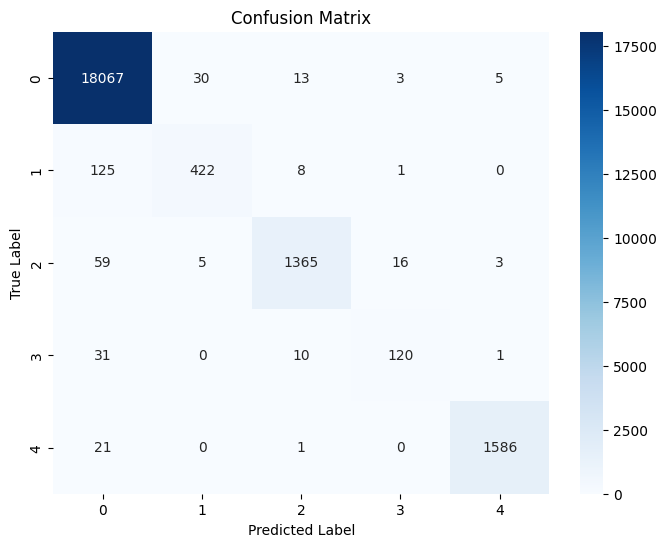

In [25]:
# Training Loop
epochs = 30
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {running_loss/len(train_loader):.4f}")
    # Compute average training loss
    train_loss = running_loss / len(train_loader)
    # Validation Phase
    model.eval()
    val_loss = 0.0
    y_pred, y_true = [], []
    with torch.no_grad():
        for inputs, labels in val_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

            _, preds = torch.max(outputs, 1)
            y_pred.extend(preds.cpu().numpy())
            y_true.extend(labels.cpu().numpy())

    # Compute average validation loss
    val_loss /= len(val_loader)

    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}")
    
# Evaluation
model.eval()
y_pred, y_true = [], []
with torch.no_grad():
    for inputs, labels in test_loader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        y_pred.extend(preds.cpu().numpy())
        y_true.extend(labels.cpu().numpy())

print(classification_report(y_true, y_pred))


# Generate classification report
report = classification_report(y_true, y_pred, output_dict=True)
# Generate confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=range(5), yticklabels=range(5))
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

In [26]:
path = "models_save/"
model_save = path + "CNN_model.pth"
#Save Trained Model:
torch.save(model.state_dict(), model_save)
print("Model saved successfully.")

Model saved successfully.
